### Assignment: Understanding Loss Functions in Machine Learning <font color='red'>**[30 points]**</font>



## Objective
The goal of this assignment is to understand different loss functions used in machine learning. Loss functions measure the difference between predicted and actual values and play a crucial role in optimizing machine learning models.

## Instructions
1. **Implement the following loss functions:**
   - Squared Loss
   - Absolute Loss
   - Huber Loss https://en.wikipedia.org/wiki/Huber_loss
   - Logistic Loss
   - Hinge Loss https://en.wikipedia.org/wiki/Hinge_loss

2. **Dataset:**
   - Generate a larger dataset with at least 100 samples where `y_true` consists of binary labels (0 or 1), and `y_pred` is a continuous array with values between 0 and 1 representing predicted probabilities.
   - You may use NumPy to generate the dataset.
   
3. **Visualization:**
   - Use Matplotlib to visualize how each loss function behaves.
   - Specifically, create the following plots:
     - **3D Plot for Each Loss Function**:
       - X-axis: `y_true` (actual labels)
       - Y-axis: `y_pred` (predicted probabilities)
       - Z-axis: Corresponding loss value
     - Generate separate 3D plots for each loss.
   
## Deliverables
- Python functions for all loss functions.
- A script to generate and test the dataset.
- 3D plots comparing the above 5 loss functions given in **#1** <font color='red'>**[5 points for each loss]**</font>
- A short explanation of the behavior of each loss function and when it is most suitable. <font color='red'>**[1 point for each loss]**</font>

## Hints
- Use `numpy.meshgrid()` to create a grid of `y_true` and `y_pred` values.
- Use `matplotlib.pyplot.plot_surface()` to generate 3D visualizations.
- Ensure numerical stability by clipping probability values in Log Loss.



In [11]:
## Step-by-Step Solution Code
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


## Generate Dataset
"""
y_true: Ground truth labels (0 or 1)
y_pred: Predicted labels (rounded to 0 or 1)
"""
def generate_dataset(n=200, seed=0):
    rng = np.random.default_rng(seed)
    y_true = rng.integers(0, 2, size=n)
    y_pred = rng.random(size=n)
    
    return y_true, y_pred


## One example for you

def indicator_loss(y_true, y_pred):
    """
    Indicator loss function:
    Returns 1 if prediction is incorrect, 0 otherwise.
    """

    y_pred_rounded = np.round(y_pred)  # Convert probabilities to binary predictions
    return np.mean(y_true != y_pred_rounded)  # Fraction of incorrect predictions

## Do the rest

def squared_loss(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    return np.mean((y_true - y_pred) ** 2)


def absolute_loss(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    return np.mean(np.abs(y_true - y_pred))
    

def huber_loss(y_true, y_pred, delta=0.2):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    r = y_true - y_pred
    abs_r = np.abs(r)
    quadratic = 0.5 * r**2
    linear = delta * (abs_r - 0.5 * delta)
    
    return np.mean(np.where(abs_r <= delta, quadratic, linear))


def logistic_loss(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    p = np.asarray(y_pred, dtype=float)
    p = np.clip(p, eps, 1.0 - eps)
    
    return np.mean(-(y_true * np.log(p) + (1.0 - y_true) * np.log(1.0 - p)))


def hinge_loss(y_true, y_pred):    
    y_true = np.asarray(y_true, dtype=float)
    p = np.asarray(y_pred, dtype=float)
    y = 2.0 * y_true - 1.0
    s = 2.0 * p - 1.0
    
    return np.mean(np.maximum(0.0, 1.0 - y * s))


def plot_loss_surface(loss_fn, title, delta=0.2, eps=1e-12):
    y_true_vals = np.array([0.0, 1.0])
    y_pred_vals = np.linspace(0.0, 1.0, 200)

    X, Y = np.meshgrid(y_true_vals, y_pred_vals)
    Z = np.zeros_like(Y, dtype=float)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            yt = X[i, j]
            yp = Y[i, j]

            if loss_fn.__name__ == "huber_loss":
                Z[i, j] = huber_loss(np.array([yt]), np.array([yp]), delta=delta)
            elif loss_fn.__name__ == "logistic_loss":
                Z[i, j] = logistic_loss(np.array([yt]), np.array([yp]), eps=eps)
            else:
                Z[i, j] = loss_fn(np.array([yt]), np.array([yp]))

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)

    ax.set_xlabel("y_true (actual label)")
    ax.set_ylabel("y_pred (predicted probability)")
    ax.set_zlabel("Loss Value", fontsize=12)
    ax.zaxis.set_rotate_label(False)
    ax.zaxis.label.set_rotation(90)
    ax.set_title(title)
    ax.set_xticks([0, 1])

    plt.tight_layout()
    plt.show()

Dataset size:  200
Squared loss:  0.31916950794620114
Absolute loss:  0.48102398213568903
Huber loss:  0.07767151146417103
Logistic loss:  0.9760066981990897
Hinge loss: 0.9620479642713781


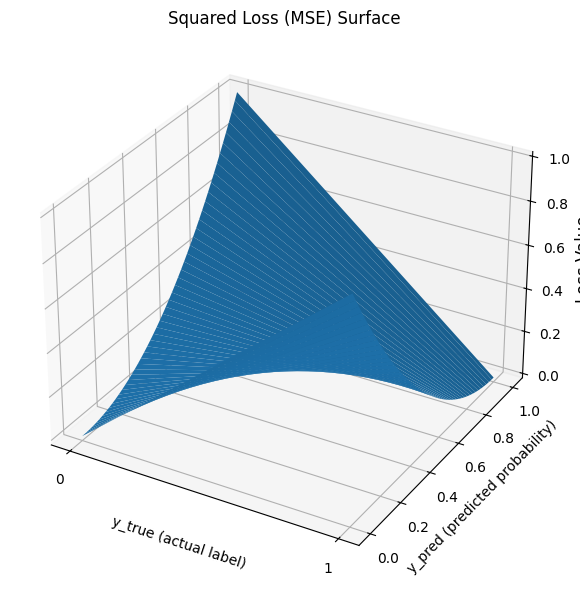

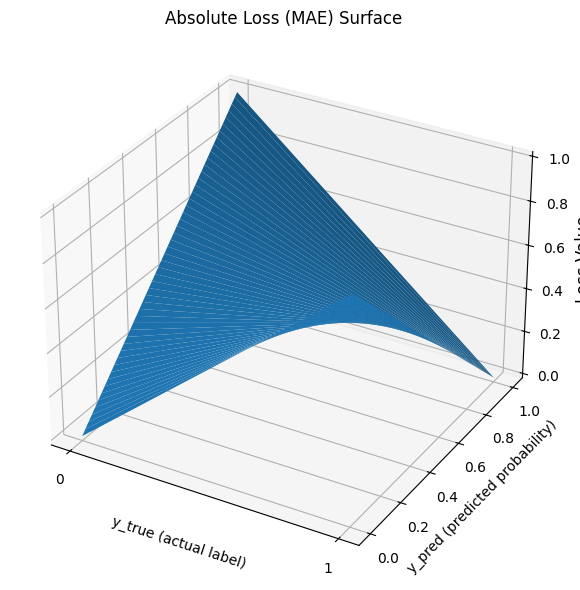

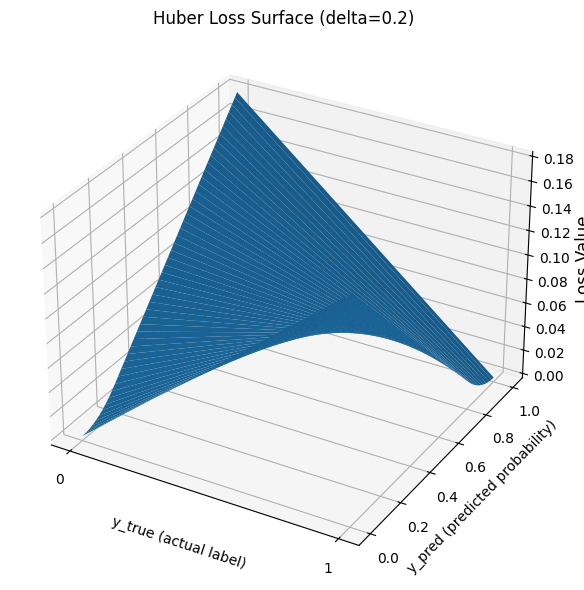

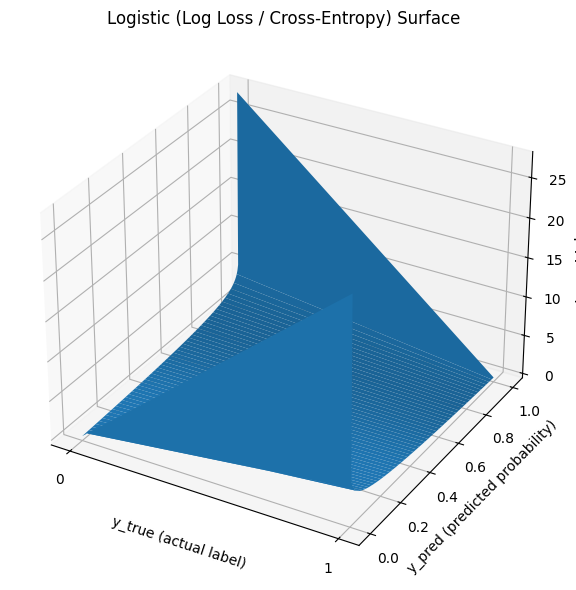

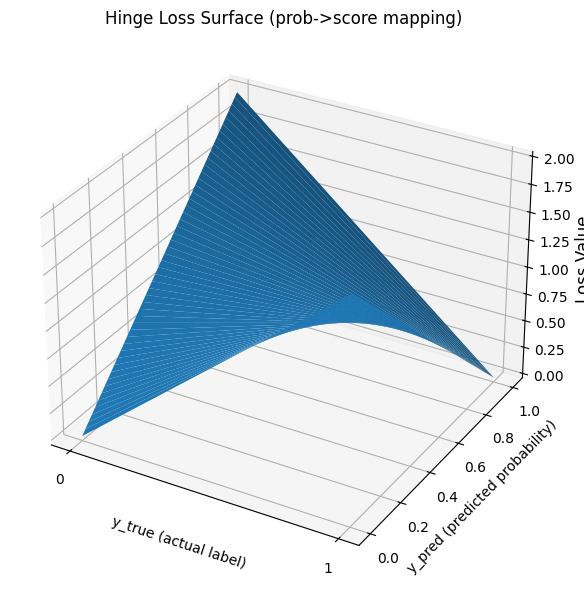

In [12]:
y_true, y_pred = generate_dataset()
print("Dataset size: ", len(y_true))
print("Squared loss: ", squared_loss(y_true, y_pred))
print("Absolute loss: ", absolute_loss(y_true, y_pred))
print("Huber loss: ", huber_loss(y_true, y_pred, delta=0.2))
print("Logistic loss: ", logistic_loss(y_true, y_pred))
print("Hinge loss:", hinge_loss(y_true, y_pred))

plot_loss_surface(squared_loss, "Squared Loss (MSE) Surface")
plot_loss_surface(absolute_loss, "Absolute Loss (MAE) Surface")
plot_loss_surface(huber_loss, "Huber Loss Surface (delta=0.2)", delta=0.2)
plot_loss_surface(logistic_loss, "Logistic (Log Loss / Cross-Entropy) Surface")
plot_loss_surface(hinge_loss, "Hinge Loss Surface (prob->score mapping)")

Loss Function Explanations:

Squared loss measures the squared difference between predicted and actual values. This results in large errors being penalized heavily because they are squared. Squared loss should be used with regression problems and when large errors should be penalized more. It also works best when smooth gradients are needed for optimization.

Absolute loss measures the absolute difference between predicted and actual values. This means that all errors are treated linearly. Absolute loss is used with regression and when equal penalties for errors are desired. It is useful when your data contains noise and extreme outliers.

Huber loss is a combination of squared loss and absolute loss. It uses squared loss for small errors and absolute loss for large errors. This means that it is less sensitive to outliers than squared loss. It is useful in regression problems where outliers are present and stable training is desired.

Logistic loss is used to measure performance in a classification model based of predicted probabilities. Confident wrong predictions are penalized heavily. It is used with binary classification problems and logistic regression and neural networks. Logistic loss is a good choice when a model's probability accuracy is important.

Hinge loss, like logistic loss, is also used in training classifiers. It is used in margin-based classification and penalizes both predictions that are confidently incorrect and not confidently incorrect. It is commonly used with support vector machines when only correct classification with margin matters rather than probability.